# 01 — Data Exploration

**Owner:** Ishanvir

## Dataset overview

BR41N.IO 2026 Spring School Hackathon SSVEP recordings, provided by g.tec.
Two healthy subjects, two training sessions each, four `.mat` files total
in `data/raw/`.

**Channel layout** (rows of `y`, 0-indexed in Python, 1-indexed below):

| Channel | Signal |
|---|---|
| CH1 | sample time (seconds since recording start) |
| CH2 | PO7 (EEG) |
| CH3 | PO3 (EEG) |
| CH4 | POz (EEG) |
| CH5 | PO4 (EEG) |
| CH6 | PO8 (EEG) |
| CH7 | O1 (EEG) |
| CH8 | Oz (EEG) |
| CH9 | O2 (EEG) |
| CH10 | trigger (0 / 9 / 10 / 12 / 15 Hz) |
| CH11 | LDA classifier output (status under investigation; see cell 13) |

**Sampling rate:** 256 Hz. 

**Stimulation frequencies:** 9, 10, 12, 15 Hz.

**Recording duration:** ~225 s/file (57697–58757 samples).

This notebook is a characterization.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import welch
from pathlib import Path
from itertools import permutations

CH_NAMES = ["PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2"]
STIM_FREQS = (9.0, 10.0, 12.0, 15.0)
DATA_DIR = Path("../data/raw") if Path("../data/raw").exists() else Path("data/raw")

DATA = {}
for path in sorted(DATA_DIR.glob("subject_*_fvep_led_training_*.mat")):
    m = sio.loadmat(path, squeeze_me=True, simplify_cells=True)
    DATA[path.stem] = {'y': m['y'], 'fs': int(m['fs'])}
    y = m['y']
    print(f"{path.stem}: shape={y.shape}, duration={y.shape[1]/m['fs']:.1f}s, fs={m['fs']} Hz")

def trials_from_trigger(trigger):
    """Return [(onset_idx, offset_idx_exclusive, freq), ...] from CH10 transitions."""
    diff = np.diff((trigger != 0).astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0]
    return [(int(s), int(e), float(trigger[s])) for s, e in zip(starts, ends)]


subject_1_fvep_led_training_1: shape=(11, 57728), duration=225.5s, fs=256 Hz
subject_1_fvep_led_training_2: shape=(11, 58112), duration=227.0s, fs=256 Hz
subject_2_fvep_led_training_1: shape=(11, 58757), duration=229.5s, fs=256 Hz
subject_2_fvep_led_training_2: shape=(11, 57697), duration=225.4s, fs=256 Hz


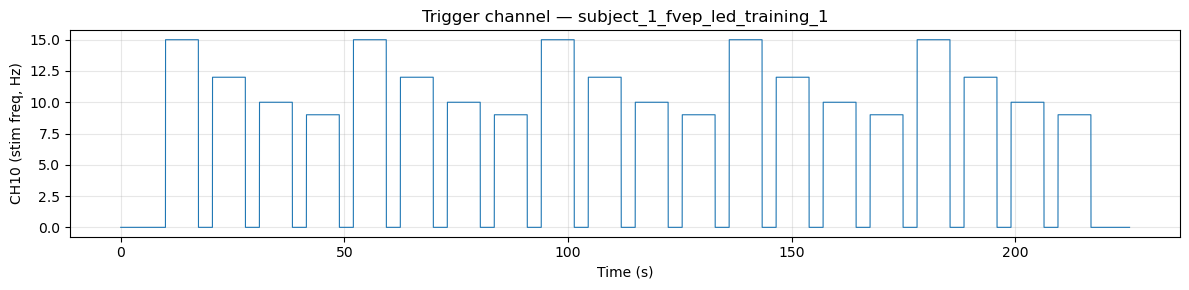

n_trials = 20
trial duration: mean=7.36s  range=[7.36, 7.36]
inter-trial gap: mean=3.14s  range=[3.14, 3.14]
trials per class: {9.0: 5, 10.0: 5, 12.0: 5, 15.0: 5}


In [2]:
KEY = "subject_1_fvep_led_training_1"
y = DATA[KEY]['y']; fs = DATA[KEY]['fs']
t = np.arange(y.shape[1]) / fs
trigger = y[9]

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, trigger, lw=0.8, color='C0')
ax.set_xlabel('Time (s)'); ax.set_ylabel('CH10 (stim freq, Hz)')
ax.set_title(f'Trigger channel — {KEY}')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

trials = trials_from_trigger(trigger)
durations = np.array([(e - s) / fs for s, e, f in trials])
gaps = np.array([(trials[i+1][0] - trials[i][1]) / fs for i in range(len(trials)-1)])
classes = [f for _, _, f in trials]
u, c = np.unique(classes, return_counts=True)
print(f'n_trials = {len(trials)}')
print(f'trial duration: mean={durations.mean():.2f}s  range=[{durations.min():.2f}, {durations.max():.2f}]')
print(f'inter-trial gap: mean={gaps.mean():.2f}s  range=[{gaps.min():.2f}, {gaps.max():.2f}]')
print(f'trials per class: {dict(zip(u.tolist(), c.tolist()))}')


### Trial structure observations

From the CH10 transitions above:

- **20 trials per file**, balanced 5-per-class across the 4 stimulation frequencies.
- **Trial duration is fixed at 7.36 s** (1883 samples @ 256 Hz).
- **Inter-trial gap is fixed at 3.14 s** (805 samples).

**Trial window for CCA-style classifiers:** 3.0 s + 0.14 s for ITR (see cca_window_sweep_nested.csv).

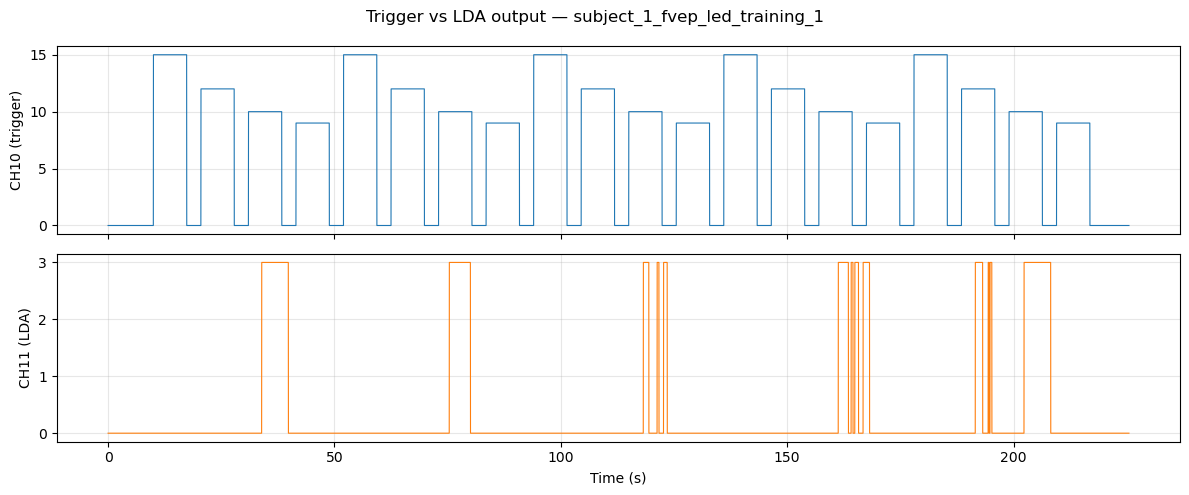

Trials where LDA fired: 7 / 20
LDA latency from stim onset: mean=2.73s  range=[0.00, 4.28]


In [3]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
ax1.plot(t, trigger, lw=0.8, color='C0')
ax1.set_ylabel('CH10 (trigger)'); ax1.grid(alpha=0.3)
ax2.plot(t, y[10], lw=0.8, color='C1')
ax2.set_ylabel('CH11 (LDA)'); ax2.set_xlabel('Time (s)'); ax2.grid(alpha=0.3)
plt.suptitle(f'Trigger vs LDA output — {KEY}')
plt.tight_layout(); plt.show()

lda = y[10]
latencies = []
fired_count = 0
for s, e, f in trials:
    nz = np.where(lda[s:e] != 0)[0]
    if nz.size > 0:
        latencies.append(nz[0] / fs)
        fired_count += 1
if latencies:
    lat = np.array(latencies)
    print(f'Trials where LDA fired: {fired_count} / {len(trials)}')
    print(f'LDA latency from stim onset: mean={lat.mean():.2f}s  range=[{lat.min():.2f}, {lat.max():.2f}]')
else:
    print('LDA never fired in this file')


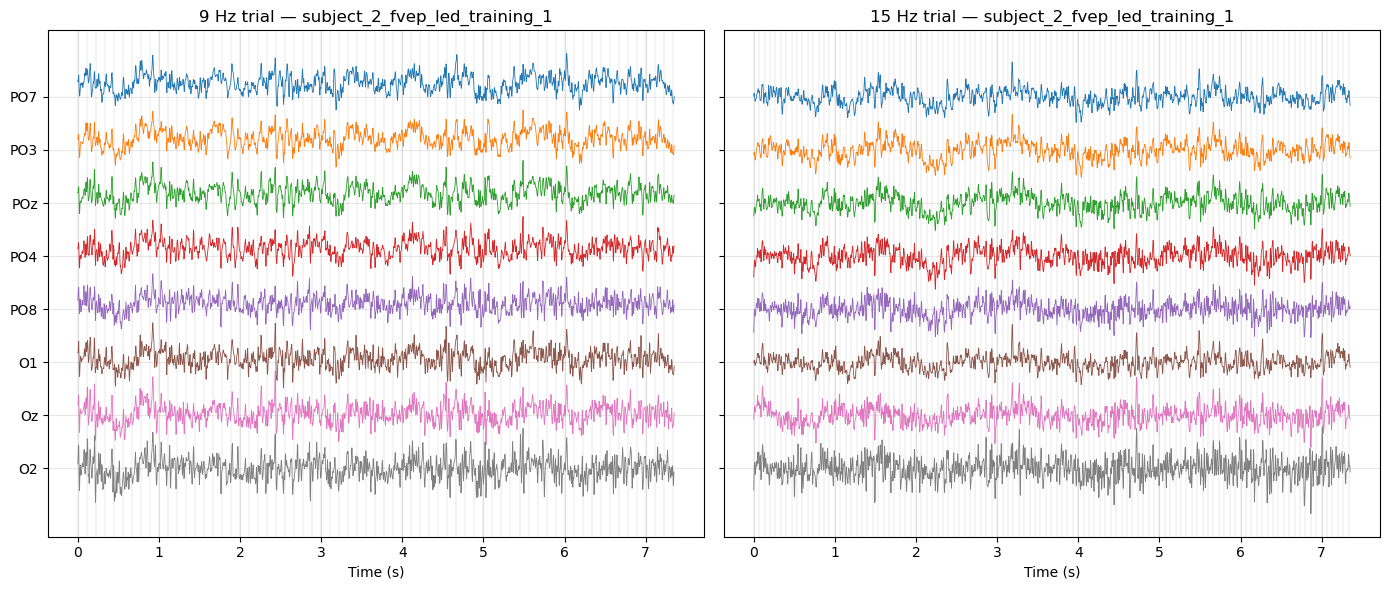

In [4]:
KEY2 = "subject_2_fvep_led_training_1"
y2 = DATA[KEY2]['y']; fs2 = DATA[KEY2]['fs']
trials2 = trials_from_trigger(y2[9])
trial_9 = next(t for t in trials2 if t[2] == 9.0)
trial_15 = next(t for t in trials2 if t[2] == 15.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, trial, freq in [(axes[0], trial_9, 9), (axes[1], trial_15, 15)]:
    s, e, _ = trial
    seg = y2[1:9, s:e]
    t_seg = np.arange(seg.shape[1]) / fs2
    spacing = float(np.std(seg)) * 6.0
    offsets = np.arange(8)[::-1] * spacing
    for ch_i in range(8):
        ax.plot(t_seg, seg[ch_i] + offsets[ch_i], lw=0.6)
    ax.set_yticks(offsets); ax.set_yticklabels(CH_NAMES)
    ax.set_xlabel('Time (s)'); ax.set_title(f'{freq} Hz trial — {KEY2}')
    ax.grid(alpha=0.3)
    for i in range(int(t_seg[-1] * freq) + 1):
        ax.axvline(i / freq, color='gray', lw=0.3, alpha=0.4)
plt.tight_layout(); plt.show()


### Visual SSVEP confirmation


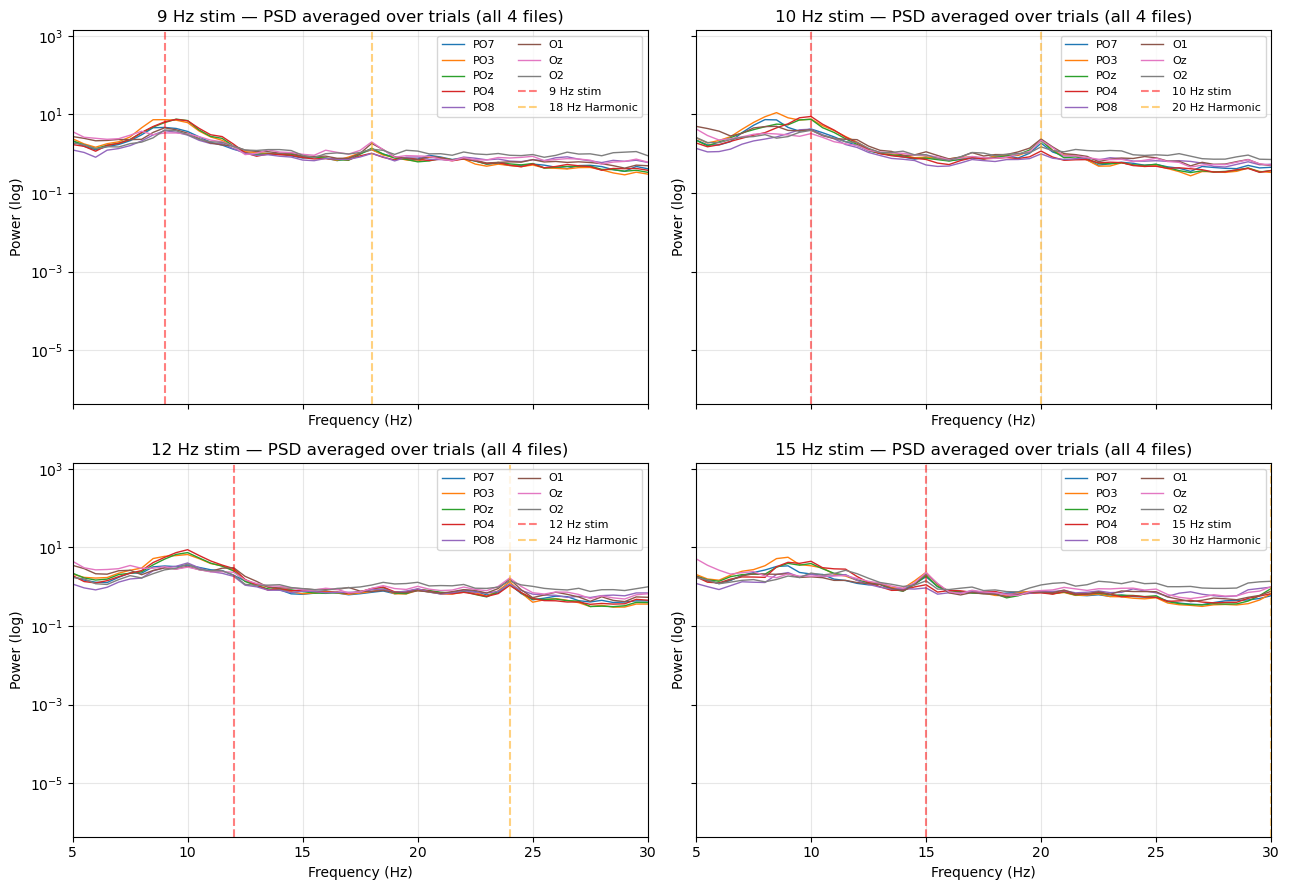

In [5]:
NPERSEG = 512  # 0.5 Hz resolution at 256 Hz fs
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, freq in zip(axes.flat, STIM_FREQS):
    psd_per_ch = [[] for _ in range(8)]
    f_grid = None
    for key, ds in DATA.items():
        y_arr = ds['y']; fs_arr = ds['fs']
        for s, e, f in trials_from_trigger(y_arr[9]):
            if f != freq:
                continue
            seg = y_arr[1:9, s:e]
            nps = min(NPERSEG, seg.shape[1])
            f_w, p_w = welch(seg, fs=fs_arr, nperseg=nps, axis=-1)
            f_grid = f_w
            for ch_i in range(8):
                psd_per_ch[ch_i].append(p_w[ch_i])
    for ch_i in range(8):
        if not psd_per_ch[ch_i]:
            continue
        avg = np.mean(psd_per_ch[ch_i], axis=0)
        ax.plot(f_grid, avg, lw=1.0, label=CH_NAMES[ch_i])
    ax.axvline(freq, color='red', ls='--', alpha=0.5, label=f'{int(freq)} Hz stim')
    ax.axvline(2*freq, color='orange', ls='--', alpha=0.5, label=f'{2*int(freq)} Hz Harmonic')
    ax.set_xlim(5, 30); ax.set_yscale('log')
    ax.set_title(f'{int(freq)} Hz stim — PSD averaged over trials (all 4 files)')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Power (log)')
    ax.legend(loc='upper right', fontsize=8, ncols=2)
    ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


### PSD observations

Welch PSD per channel, averaged over 20 trials per panel (5+5 × 2 subjects) at each stim frequency. Red dashed = stim, orange = 2× harmonic.

- PO3/POz/PO4 lead at 9, 10 Hz. O1/Oz/O2 lead marginally at 12, 15 Hz. Subject 2 drives the lower-freq inversion — see notebook 08.
- Harmonic peaks at 2× and 3× stim are visible (SSVEP is non-sinusoidal). Data is clean.


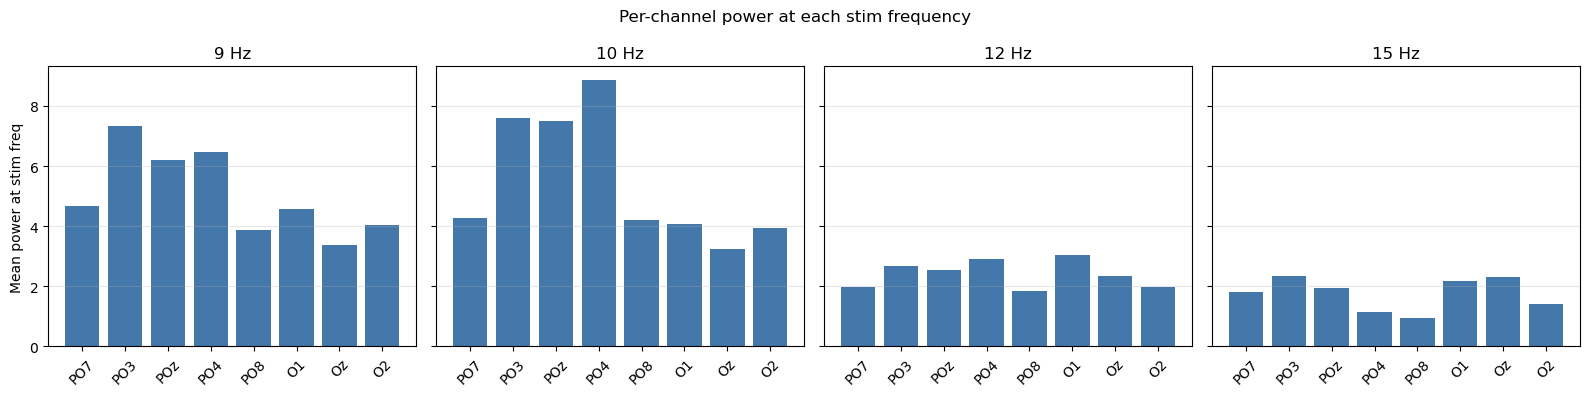

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, freq in zip(axes, STIM_FREQS):
    powers = np.zeros(8); count = 0
    for key, ds in DATA.items():
        y_arr = ds['y']; fs_arr = ds['fs']
        for s, e, f in trials_from_trigger(y_arr[9]):
            if f != freq:
                continue
            seg = y_arr[1:9, s:e]
            nps = min(NPERSEG, seg.shape[1])
            f_w, p_w = welch(seg, fs=fs_arr, nperseg=nps, axis=-1)
            idx = int(np.argmin(np.abs(f_w - freq)))
            powers += p_w[:, idx]; count += 1
    if count > 0:
        powers /= count
    bars = ax.bar(CH_NAMES, powers, color='#4477AA')
    ax.set_title(f'{int(freq)} Hz')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('Mean power at stim freq')
fig.suptitle('Per-channel power at each stim frequency')
plt.tight_layout(); plt.show()


### Channel selection note

Bar plot (cell 9): PO ring (PO3/POz/PO4) leads at 9, 10 Hz. O1/Oz/O2 lead marginally at 12, 15 Hz. S1 occipital, S2 PO-ring; aggregate inversion is S2-driven.

→ Keep all 8 channels for the CCA-family baseline. Per-subject 4-channel subsets in notebook 08.


In [7]:
def sweep_permutations(lda_arr, trigger_arr, freqs=STIM_FREQS):
    base = sorted(freqs)
    out = []
    for perm in permutations(base):
        m = {float(i + 1): float(f) for i, f in enumerate(perm)}
        mapped = np.vectorize(lambda x: m.get(float(x), -1.0))(lda_arr)
        out.append((float(np.mean(mapped == trigger_arr)), perm))
    return sorted(out, key=lambda t: t[0], reverse=True)

all_lda, all_trig = [], []
for key, ds in DATA.items():
    y_arr = ds['y']
    trig = y_arr[9]; lda_arr = y_arr[10]
    scored = (trig != 0) & (lda_arr != 0)
    all_lda.append(lda_arr[scored]); all_trig.append(trig[scored])
all_lda = np.concatenate(all_lda); all_trig = np.concatenate(all_trig)

ranking = sweep_permutations(all_lda, all_trig)
print(f'Per-sample sweep across all 4 files, n_scored = {all_lda.size}')
print('Top-3 permutations:')
for acc, perm in ranking[:3]:
    mapping_str = ', '.join(f'{i+1}: {int(f)} Hz' for i, f in enumerate(perm))
    print(f'  acc={acc:.3f}  mapping={{{mapping_str}}}')
best_acc, best_perm = ranking[0]
print('\nBest per-sample mapping: {' + ', '.join(f"{i+1}: {int(f)} Hz" for i, f in enumerate(best_perm)) + '}')
print(f'Best per-sample accuracy: {best_acc:.3f}')

# Per-trial majority vote at trial end (last WINDOW_END samples, nonzero LDA values).
# This mirrors how a real BCI would use the LDA: one decision per trial, taken
# at the end of the stim window. Per-sample accuracy is diluted by trials where
# the LDA never fires (sticky / no-coverage); per-trial answers 'when the LDA
# does emit a prediction at trial end, how often is it right?'.
WINDOW_END = 100  # ~0.39 s at 256 Hz
best_mapping = {float(i + 1): float(f) for i, f in enumerate(best_perm)}
per_file_trial = {}
tot_correct = tot_eval = tot_skipped = tot_trials = 0
for key, ds in DATA.items():
    y_arr = ds['y']
    trig = y_arr[9]; lda_arr = y_arr[10]
    correct = skipped = 0
    trials_local = trials_from_trigger(trig)
    for s, e, true_freq in trials_local:
        win = lda_arr[max(s, e - WINDOW_END):e]
        nz = win[win != 0]
        if nz.size == 0:
            skipped += 1
            continue
        vals, cnts = np.unique(nz, return_counts=True)
        pred_class = float(vals[np.argmax(cnts)])
        pred_freq = best_mapping.get(pred_class, -1.0)
        if pred_freq == true_freq:
            correct += 1
    n_eval = len(trials_local) - skipped
    acc_local = correct / n_eval if n_eval > 0 else float('nan')
    per_file_trial[key] = (correct, n_eval, len(trials_local), acc_local)
    tot_correct += correct; tot_eval += n_eval
    tot_skipped += skipped; tot_trials += len(trials_local)

print(f'\nPer-trial majority vote (last {WINDOW_END} samples, mapping from best per-sample perm):')
for key, (c, ev, tot, acc_l) in per_file_trial.items():
    print(f'  {key}: {c}/{ev} (acc={acc_l:.3f}), skipped {tot - ev}/{tot} no-fire')
trial_acc = tot_correct / tot_eval if tot_eval > 0 else float('nan')
print(f'\nOverall per-trial:')
print(f'  trials evaluated: {tot_eval} / {tot_trials} (skipped {tot_skipped} with no LDA fire in window)')
print(f'  per-trial accuracy: {trial_acc:.3f}')


Per-sample sweep across all 4 files, n_scored = 48402
Top-3 permutations:
  acc=0.677  mapping={1: 15 Hz, 2: 12 Hz, 3: 10 Hz, 4: 9 Hz}
  acc=0.477  mapping={1: 12 Hz, 2: 15 Hz, 3: 10 Hz, 4: 9 Hz}
  acc=0.458  mapping={1: 15 Hz, 2: 9 Hz, 3: 10 Hz, 4: 12 Hz}

Best per-sample mapping: {1: 15 Hz, 2: 12 Hz, 3: 10 Hz, 4: 9 Hz}
Best per-sample accuracy: 0.677

Per-trial majority vote (last 100 samples, mapping from best per-sample perm):
  subject_1_fvep_led_training_1: 4/4 (acc=1.000), skipped 16/20 no-fire
  subject_1_fvep_led_training_2: 6/6 (acc=1.000), skipped 14/20 no-fire
  subject_2_fvep_led_training_1: 13/14 (acc=0.929), skipped 6/20 no-fire
  subject_2_fvep_led_training_2: 11/15 (acc=0.733), skipped 5/20 no-fire

Overall per-trial:
  trials evaluated: 39 / 80 (skipped 41 with no LDA fire in window)
  per-trial accuracy: 0.872


### CH11 diagnostic

Two complementary scoring views from cell 13:

- **Per-sample accuracy** ≈ **0.677** across 48,402 scored samples (every sample
  where stim is active *and* CH11 has fired).
- **Per-trial accuracy** ≈ **0.872** on the 39 / 80 trials where the LDA emits
  a prediction in the last 100 samples (~0.39 s) of the trial. The other
  41 / 80 trials are **skipped** because CH11 never fires near trial end.

Best mapping (recovered by brute-forcing all 24 permutations):
`{1: 15 Hz, 2: 12 Hz, 3: 10 Hz, 4: 9 Hz}` — descending frequency, not ascending.

**Why the two numbers differ.** Per-sample treats every sample independently and
is dragged down by sticky values (CH11 holding a stale prediction from earlier in
the trial) and by long stretches where CH11 never updates. Per-trial mirrors how
a real BCI would use the LDA — one majority-vote decision at trial end — and is
the BCI-relevant number.

Apply the diagnostic thresholds to the **per-trial** number, since that is what a
user would actually feel:

| Bucket | What it means |
|---|---|
| ≥ 0.85 | CH11 **is** g.tec's live LDA classifier. SOTA-baseline strategy proceeds. |
| 0.50 – 0.85 | CH11 is **most likely** the LDA but partial / noisy / latency-misaligned. |
| < 0.30 | CH11 is **not** what we think. Replan. |

**0.872 lands at the top of the upper bucket** — we can treat CH11 as the SOTA
reference *for the trials where it fires*. Caveats:

1. **Coverage is the real problem, not accuracy.** 51% of trials have no LDA
   prediction in the last 100 samples. We need to either widen the window
   (last 500 ms? 1 s?) or accept that CH11 only covers ~half the dataset.
2. **Subject 2 training 2 is the weakest run.** Per-trial: 11/15 = 73% (vs 100%
   for both subject 1 sessions on their evaluable trials). Worth investigating
   whether this reflects classifier drift, EEG quality, or a session-specific
   artefact before averaging it into our SOTA reference.
3. **Per-file per-trial breakdown:**
   - subject_1_training_1: 4/4 = **1.000** (16/20 skipped)
   - subject_1_training_2: 6/6 = **1.000** (14/20 skipped)
   - subject_2_training_1: 13/14 = **0.929** (6/20 skipped)
   - subject_2_training_2: 11/15 = **0.733** (5/20 skipped)


## Conclusions and decisions for the team

- **CH11 status:** likely g.tec's live LDA classifier. Per-sample acc 0.677
  (diluted by sticky values + no-fire samples); per-trial majority-vote acc
  **0.872** on the 39/80 trials with LDA fire in the last 100 samples. Mapping
  is `{1: 15, 2: 12, 3: 10, 4: 9}` (descending). The real issue isn't accuracy —
  it's coverage: **51% of trials have no LDA prediction near trial end**.
  _TBD: widen the per-trial window (250 ms? 500 ms?) or accept partial coverage._
- **Trial window:** 3.0 s + 0.14 s drop. ITR-optimized; sweep in cca_window_sweep_nested.csv. Trial structure is rigid: 7.36 s stim + 3.14 s gap, 5 trials per class per file.
- **Channel selection:** all 8 channels (cell 11 conditional failed). Per-subject top-4 lives in notebook 08.
- **Open questions:**
  - Why is subject 2's CH11 accuracy ~30 points lower than subject 1's? Drift
    in the LDA between training_1 and training_2 within subject?
  - Does dropping the first 0.5 s of each trial improve our CCA baseline
    enough to justify the data loss, or should we use the full 7.36 s window?
  - Is `data/raw/montage.png` the canonical channel order? Confirm CH2–9 ordering
    matches the montage figure's labels (PO7, PO3, POz, PO4, PO8, O1, Oz, O2).
